# Feedback Loop & Model Monitoring

This notebook implements a closed-loop system for:
1. **Segment Evolution Tracking** - Monitor customer movement between segments
2. **Campaign Performance Simulation** - Simulate targeting and measure lift
3. **Model Monitoring & Drift Detection** - Track model degradation
4. **A/B Testing Framework** - Design and analyze experiments

**Input:** `data/customers_final.csv`  
**Output:** `data/feedback_metrics.csv`, `data/campaign_results.csv`

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load final customer data
df = pd.read_csv('data/customers_final.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nKey columns for feedback loop:")
print(f"  - Segments: action_segment, clv_tier, churn_risk_segment")
print(f"  - Predictions: churn_probability, clv_predicted")
print(f"  - Actions: clv_churn_action")

Dataset shape: (5000, 59)

Key columns for feedback loop:
  - Segments: action_segment, clv_tier, churn_risk_segment
  - Predictions: churn_probability, clv_predicted
  - Actions: clv_churn_action


---
## 2. Segment Evolution Tracking

Simulate customer segment transitions over time to understand segment stability and validate predictions.

In [3]:
def simulate_segment_evolution(df, n_periods=6, transition_noise=0.15):
    """
    Simulate how customers might transition between segments over time.
    Higher churn risk = more likely to move to worse segments.
    Higher engagement = more likely to move to better segments.
    """
    clv_tiers = ['Bronze', 'Silver', 'Gold', 'Platinum', 'Diamond']
    tier_to_idx = {t: i for i, t in enumerate(clv_tiers)}
    
    evolution_data = []
    
    for period in range(n_periods + 1):
        period_df = df.copy()
        period_df['period'] = period
        
        if period > 0:
            # Simulate transitions based on churn probability and engagement
            for idx in period_df.index:
                current_tier = period_df.loc[idx, 'clv_tier']
                churn_prob = period_df.loc[idx, 'churn_probability']
                engagement = period_df.loc[idx, 'engagement_score']
                
                current_idx = tier_to_idx.get(current_tier, 2)
                
                # Transition probability
                # High churn = likely to drop tier, high engagement = likely to rise
                transition_score = (engagement - 0.5) - (churn_prob - 0.5) + np.random.normal(0, transition_noise)
                
                if transition_score > 0.3 and current_idx < 4:
                    new_idx = current_idx + 1  # Move up
                elif transition_score < -0.3 and current_idx > 0:
                    new_idx = current_idx - 1  # Move down
                else:
                    new_idx = current_idx  # Stay
                
                period_df.loc[idx, 'clv_tier'] = clv_tiers[new_idx]
        
        evolution_data.append(period_df[['clv_tier', 'churn_risk_segment', 'period']].copy())
    
    return pd.concat(evolution_data, ignore_index=True)

evolution_df = simulate_segment_evolution(df)
print(f"Evolution data shape: {evolution_df.shape}")

Evolution data shape: (35000, 3)


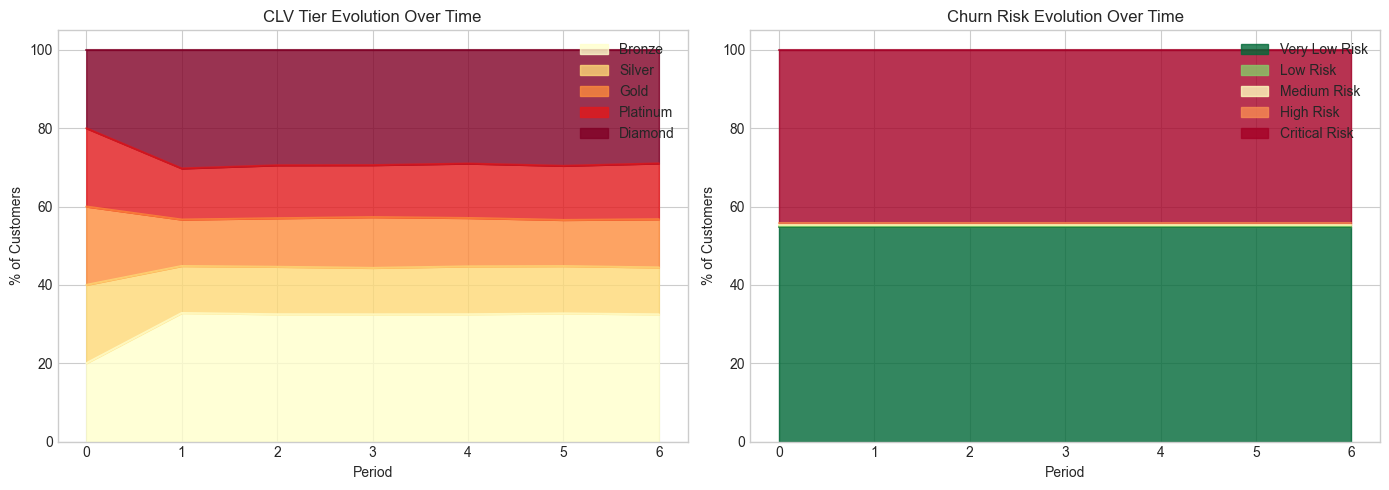

In [4]:
# Visualize segment evolution over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CLV tier evolution
clv_evolution = evolution_df.groupby(['period', 'clv_tier']).size().unstack(fill_value=0)
clv_evolution = clv_evolution[['Bronze', 'Silver', 'Gold', 'Platinum', 'Diamond']]
clv_evolution_pct = clv_evolution.div(clv_evolution.sum(axis=1), axis=0) * 100

clv_evolution_pct.plot(kind='area', stacked=True, ax=axes[0], 
                       colormap='YlOrRd', alpha=0.8)
axes[0].set_xlabel('Period')
axes[0].set_ylabel('% of Customers')
axes[0].set_title('CLV Tier Evolution Over Time')
axes[0].legend(loc='upper right')

# Churn risk evolution
churn_evolution = evolution_df.groupby(['period', 'churn_risk_segment']).size().unstack(fill_value=0)
risk_order = ['Very Low Risk', 'Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
churn_evolution = churn_evolution.reindex(columns=[c for c in risk_order if c in churn_evolution.columns])
churn_evolution_pct = churn_evolution.div(churn_evolution.sum(axis=1), axis=0) * 100

churn_evolution_pct.plot(kind='area', stacked=True, ax=axes[1],
                         colormap='RdYlGn_r', alpha=0.8)
axes[1].set_xlabel('Period')
axes[1].set_ylabel('% of Customers')
axes[1].set_title('Churn Risk Evolution Over Time')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

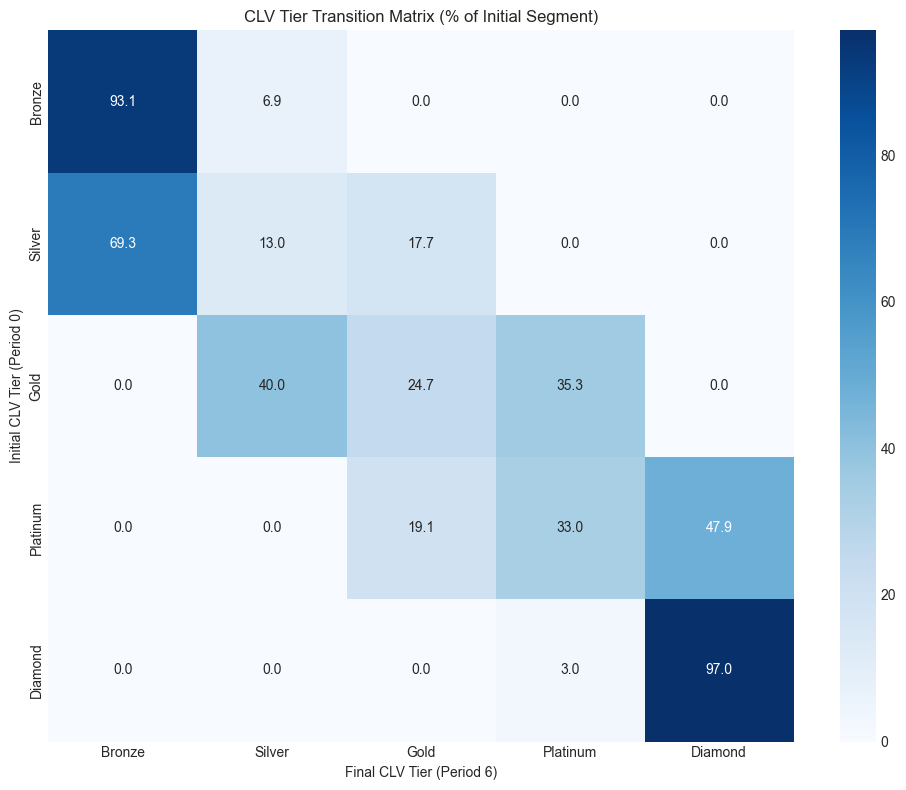


Segment Retention Rates:
Bronze      93.1
Silver      13.0
Gold        24.7
Platinum    33.0
Diamond     97.0
dtype: float64


In [5]:
# Calculate segment transition matrix (period 0 to period 6)
initial = evolution_df[evolution_df['period'] == 0]['clv_tier'].reset_index(drop=True)
final = evolution_df[evolution_df['period'] == 6]['clv_tier'].reset_index(drop=True)

transition_matrix = pd.crosstab(initial, final, normalize='index') * 100
transition_matrix = transition_matrix.reindex(
    index=['Bronze', 'Silver', 'Gold', 'Platinum', 'Diamond'],
    columns=['Bronze', 'Silver', 'Gold', 'Platinum', 'Diamond']
).fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(transition_matrix, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=transition_matrix.columns,
            yticklabels=transition_matrix.index)
plt.xlabel('Final CLV Tier (Period 6)')
plt.ylabel('Initial CLV Tier (Period 0)')
plt.title('CLV Tier Transition Matrix (% of Initial Segment)')
plt.tight_layout()
plt.show()

# Calculate retention rates
retention_rates = pd.Series({tier: transition_matrix.loc[tier, tier] for tier in transition_matrix.index})
print("\nSegment Retention Rates:")
print(retention_rates.round(1))

---
## 3. Campaign Performance Simulation

Simulate marketing campaigns targeting specific segments and measure incremental lift.

In [6]:
def simulate_campaign(df, target_segment, campaign_type, base_conversion=0.05, lift_factor=1.5):
    """
    Simulate a marketing campaign targeting a specific segment.
    Returns conversion metrics for treatment vs control.
    """
    # Identify target customers
    target_mask = df['clv_churn_action'].str.contains(target_segment, case=False, na=False)
    target_customers = df[target_mask].copy()
    
    if len(target_customers) == 0:
        return None
    
    # Split into treatment and control (50/50)
    n_target = len(target_customers)
    treatment_idx = np.random.choice(target_customers.index, size=n_target//2, replace=False)
    control_idx = target_customers.index.difference(treatment_idx)
    
    # Simulate conversions
    # Base conversion modified by customer characteristics
    def calc_conversion_prob(row, is_treatment):
        prob = base_conversion
        prob *= (1 + row['engagement_score'])  # Higher engagement = higher conversion
        prob *= (1 - row['churn_probability'] * 0.5)  # Higher churn risk = lower conversion
        if is_treatment:
            prob *= lift_factor  # Campaign lift
        return min(prob, 0.95)
    
    # Treatment group
    treatment_probs = df.loc[treatment_idx].apply(lambda r: calc_conversion_prob(r, True), axis=1)
    treatment_conversions = np.random.binomial(1, treatment_probs)
    
    # Control group
    control_probs = df.loc[control_idx].apply(lambda r: calc_conversion_prob(r, False), axis=1)
    control_conversions = np.random.binomial(1, control_probs)
    
    # Calculate metrics
    treatment_rate = treatment_conversions.mean()
    control_rate = control_conversions.mean()
    lift = (treatment_rate - control_rate) / control_rate * 100 if control_rate > 0 else 0
    
    # Statistical significance (two-proportion z-test)
    n1, n2 = len(treatment_conversions), len(control_conversions)
    p1, p2 = treatment_rate, control_rate
    p_pooled = (p1 * n1 + p2 * n2) / (n1 + n2)
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n1 + 1/n2))
    z_stat = (p1 - p2) / se if se > 0 else 0
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    
    return {
        'segment': target_segment,
        'campaign_type': campaign_type,
        'n_treatment': len(treatment_idx),
        'n_control': len(control_idx),
        'treatment_rate': treatment_rate,
        'control_rate': control_rate,
        'lift_pct': lift,
        'p_value': p_value,
        'significant': p_value < 0.05
    }

In [7]:
# Define campaigns for different segments
campaigns = [
    ('URGENT', 'Win-Back Email', 0.03, 2.0),
    ('VIP Retain', 'Loyalty Reward', 0.08, 1.3),
    ('VIP Proactive', 'Early Access Offer', 0.06, 1.5),
    ('Re-engagement', 'Discount Campaign', 0.04, 1.8),
    ('Growth', 'Upsell Campaign', 0.07, 1.4),
]

# Run simulations
campaign_results = []
for segment, campaign_type, base_conv, lift in campaigns:
    result = simulate_campaign(df, segment, campaign_type, base_conv, lift)
    if result:
        campaign_results.append(result)

campaign_df = pd.DataFrame(campaign_results)
print("Campaign Simulation Results:")
print(campaign_df.to_string(index=False))

Campaign Simulation Results:
      segment      campaign_type  n_treatment  n_control  treatment_rate  control_rate   lift_pct  p_value  significant
       URGENT     Win-Back Email          112        113        0.071429      0.026549 169.047619 0.118536        False
   VIP Retain     Loyalty Reward          885        885        0.162712      0.120904  34.579439 0.011702         True
VIP Proactive Early Access Offer            2          3        0.000000      0.000000   0.000000 1.000000        False
Re-engagement  Discount Campaign          558        558        0.051971      0.023297 123.076923 0.011847         True
       Growth    Upsell Campaign          437        437        0.107551      0.089245  20.512821 0.363605        False


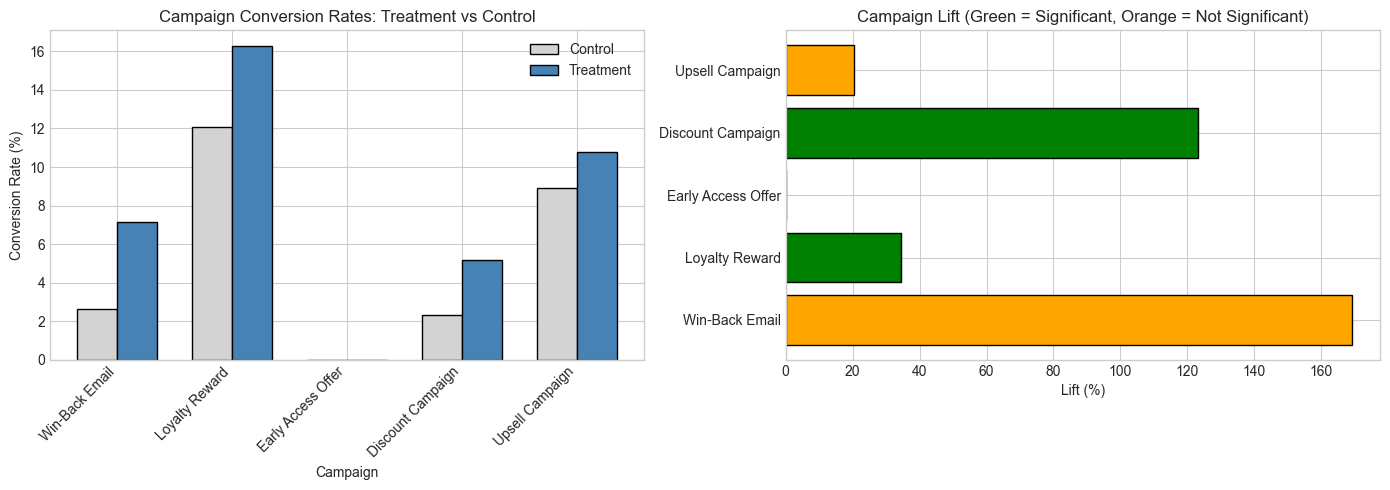

In [8]:
# Visualize campaign performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conversion rates comparison
x = np.arange(len(campaign_df))
width = 0.35

axes[0].bar(x - width/2, campaign_df['control_rate'] * 100, width, label='Control', color='lightgray', edgecolor='black')
axes[0].bar(x + width/2, campaign_df['treatment_rate'] * 100, width, label='Treatment', color='steelblue', edgecolor='black')
axes[0].set_xlabel('Campaign')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Campaign Conversion Rates: Treatment vs Control')
axes[0].set_xticks(x)
axes[0].set_xticklabels(campaign_df['campaign_type'], rotation=45, ha='right')
axes[0].legend()

# Lift percentage
colors = ['green' if sig else 'orange' for sig in campaign_df['significant']]
axes[1].barh(campaign_df['campaign_type'], campaign_df['lift_pct'], color=colors, edgecolor='black')
axes[1].axvline(0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('Lift (%)')
axes[1].set_title('Campaign Lift (Green = Significant, Orange = Not Significant)')

plt.tight_layout()
plt.show()

In [9]:
# Calculate ROI for each campaign
# Assume: cost per contact = $1, revenue per conversion = $100
cost_per_contact = 1
revenue_per_conversion = 100

campaign_df['total_cost'] = campaign_df['n_treatment'] * cost_per_contact
campaign_df['incremental_conversions'] = (campaign_df['treatment_rate'] - campaign_df['control_rate']) * campaign_df['n_treatment']
campaign_df['incremental_revenue'] = campaign_df['incremental_conversions'] * revenue_per_conversion
campaign_df['roi'] = (campaign_df['incremental_revenue'] - campaign_df['total_cost']) / campaign_df['total_cost'] * 100

print("\nCampaign ROI Analysis:")
print(campaign_df[['campaign_type', 'segment', 'incremental_conversions', 'incremental_revenue', 'total_cost', 'roi']].round(2).to_string(index=False))


Campaign ROI Analysis:
     campaign_type       segment  incremental_conversions  incremental_revenue  total_cost     roi
    Win-Back Email        URGENT                     5.03               502.65         112  348.80
    Loyalty Reward    VIP Retain                    37.00              3700.00         885  318.08
Early Access Offer VIP Proactive                     0.00                 0.00           2 -100.00
 Discount Campaign Re-engagement                    16.00              1600.00         558  186.74
   Upsell Campaign        Growth                     8.00               800.00         437   83.07


---
## 4. Model Monitoring & Drift Detection

Monitor model performance over time and detect data drift that may require retraining.

In [10]:
def simulate_data_drift(df, n_periods=12, drift_start=6, drift_magnitude=0.3):
    """
    Simulate data drift over time.
    After drift_start, feature distributions begin to shift.
    """
    monitoring_data = []
    
    for period in range(n_periods):
        period_df = df.copy()
        
        # Introduce drift after drift_start
        if period >= drift_start:
            drift_amount = (period - drift_start + 1) * drift_magnitude / (n_periods - drift_start)
            
            # Shift key features
            period_df['days_since_last_purchase'] = period_df['days_since_last_purchase'] * (1 + drift_amount * 0.5)
            period_df['engagement_score'] = np.clip(period_df['engagement_score'] * (1 - drift_amount * 0.3), 0, 1)
            period_df['total_purchases_12m'] = np.clip(period_df['total_purchases_12m'] * (1 - drift_amount * 0.2), 0, 100)
            
            # Recalculate churn probability (simulating model becoming stale)
            # True churn increases, but model predictions stay the same
            period_df['true_churn'] = np.random.binomial(
                1, 
                np.clip(period_df['churn_probability'] + drift_amount * 0.2, 0, 1)
            )
        else:
            period_df['true_churn'] = np.random.binomial(1, period_df['churn_probability'])
        
        # Calculate model performance metrics
        predicted_churn = (period_df['churn_probability'] > 0.5).astype(int)
        
        metrics = {
            'period': period,
            'auc': roc_auc_score(period_df['true_churn'], period_df['churn_probability']),
            'precision': precision_score(period_df['true_churn'], predicted_churn, zero_division=0),
            'recall': recall_score(period_df['true_churn'], predicted_churn, zero_division=0),
            'actual_churn_rate': period_df['true_churn'].mean(),
            'predicted_churn_rate': predicted_churn.mean(),
            'avg_days_since_purchase': period_df['days_since_last_purchase'].mean(),
            'avg_engagement': period_df['engagement_score'].mean()
        }
        monitoring_data.append(metrics)
    
    return pd.DataFrame(monitoring_data)

monitoring_df = simulate_data_drift(df)
print("Model Monitoring Data:")
print(monitoring_df.round(3))

Model Monitoring Data:
    period    auc  precision  recall  actual_churn_rate  predicted_churn_rate  \
0        0  0.999      0.990   0.984              0.450                 0.447   
1        1  0.999      0.985   0.985              0.448                 0.447   
2        2  0.998      0.991   0.984              0.451                 0.447   
3        3  0.999      0.987   0.991              0.446                 0.447   
4        4  0.998      0.983   0.982              0.448                 0.447   
5        5  0.998      0.984   0.988              0.445                 0.447   
6        6  0.992      0.994   0.974              0.457                 0.447   
7        7  0.988      0.990   0.963              0.460                 0.447   
8        8  0.981      0.993   0.949              0.468                 0.447   
9        9  0.977      0.993   0.942              0.472                 0.447   
10      10  0.970      0.999   0.928              0.481                 0.447   
11   

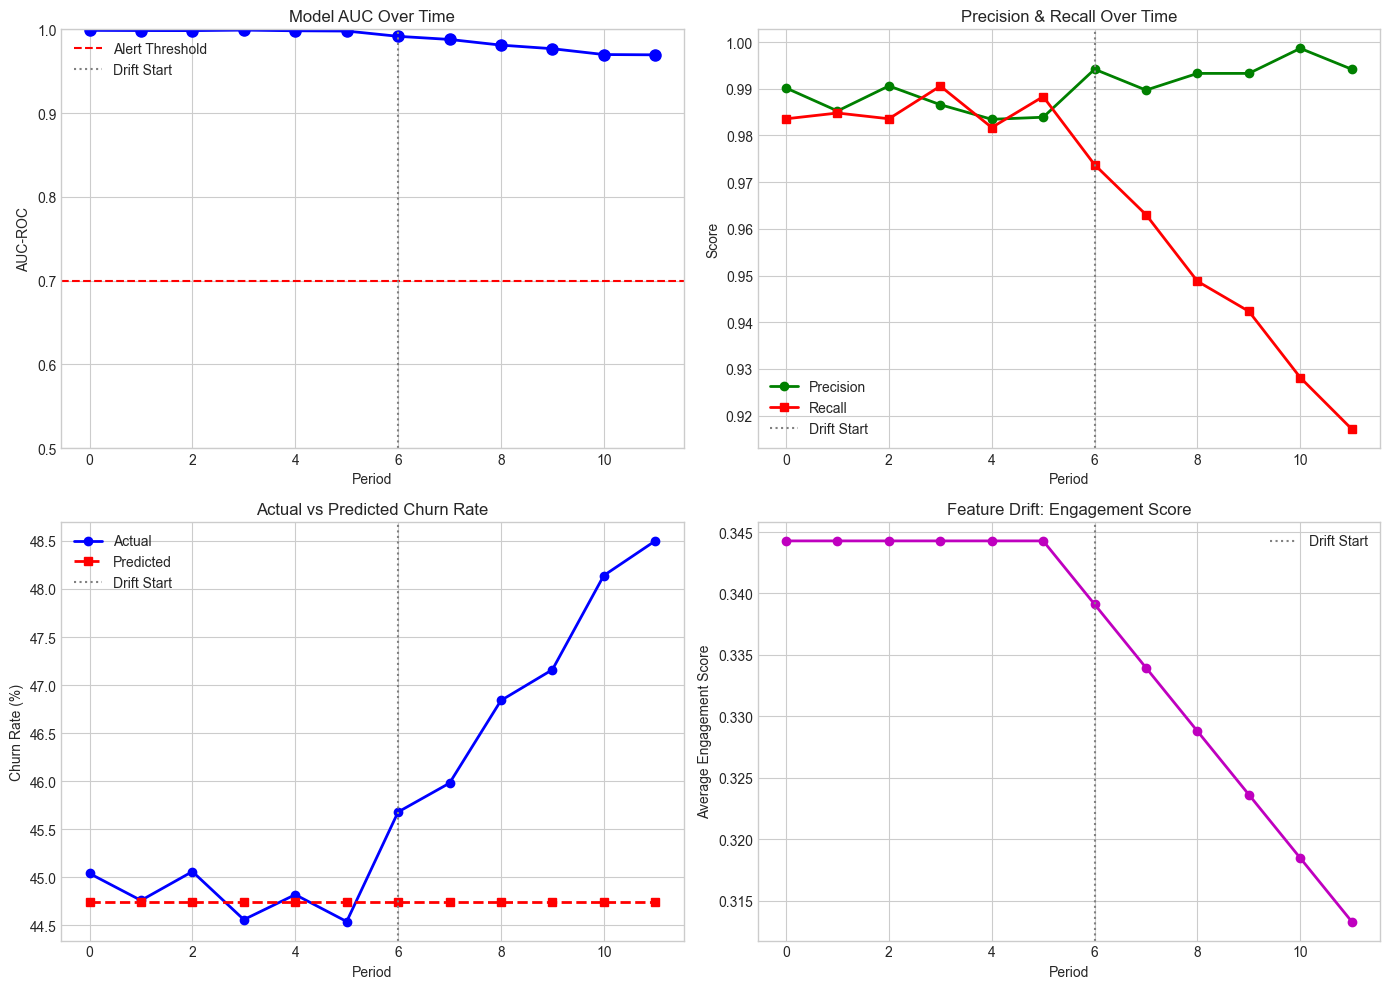

In [11]:
# Visualize model performance degradation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# AUC over time
axes[0, 0].plot(monitoring_df['period'], monitoring_df['auc'], 'b-o', linewidth=2, markersize=8)
axes[0, 0].axhline(0.7, color='red', linestyle='--', label='Alert Threshold')
axes[0, 0].axvline(6, color='gray', linestyle=':', label='Drift Start')
axes[0, 0].set_xlabel('Period')
axes[0, 0].set_ylabel('AUC-ROC')
axes[0, 0].set_title('Model AUC Over Time')
axes[0, 0].legend()
axes[0, 0].set_ylim(0.5, 1.0)

# Precision and Recall
axes[0, 1].plot(monitoring_df['period'], monitoring_df['precision'], 'g-o', label='Precision', linewidth=2)
axes[0, 1].plot(monitoring_df['period'], monitoring_df['recall'], 'r-s', label='Recall', linewidth=2)
axes[0, 1].axvline(6, color='gray', linestyle=':', label='Drift Start')
axes[0, 1].set_xlabel('Period')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Precision & Recall Over Time')
axes[0, 1].legend()

# Actual vs Predicted Churn Rate
axes[1, 0].plot(monitoring_df['period'], monitoring_df['actual_churn_rate'] * 100, 'b-o', label='Actual', linewidth=2)
axes[1, 0].plot(monitoring_df['period'], monitoring_df['predicted_churn_rate'] * 100, 'r--s', label='Predicted', linewidth=2)
axes[1, 0].axvline(6, color='gray', linestyle=':', label='Drift Start')
axes[1, 0].set_xlabel('Period')
axes[1, 0].set_ylabel('Churn Rate (%)')
axes[1, 0].set_title('Actual vs Predicted Churn Rate')
axes[1, 0].legend()

# Feature drift (engagement score)
axes[1, 1].plot(monitoring_df['period'], monitoring_df['avg_engagement'], 'm-o', linewidth=2)
axes[1, 1].axvline(6, color='gray', linestyle=':', label='Drift Start')
axes[1, 1].set_xlabel('Period')
axes[1, 1].set_ylabel('Average Engagement Score')
axes[1, 1].set_title('Feature Drift: Engagement Score')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [12]:
# Drift detection alerts
def generate_alerts(monitoring_df, auc_threshold=0.7, drift_threshold=0.1):
    """Generate alerts when model performance drops or drift is detected."""
    alerts = []
    
    baseline_auc = monitoring_df.loc[0, 'auc']
    baseline_engagement = monitoring_df.loc[0, 'avg_engagement']
    
    for _, row in monitoring_df.iterrows():
        period = row['period']
        
        # AUC drop alert
        if row['auc'] < auc_threshold:
            alerts.append({
                'period': period,
                'alert_type': 'MODEL_DEGRADATION',
                'severity': 'HIGH',
                'message': f"AUC dropped to {row['auc']:.3f} (threshold: {auc_threshold})",
                'action': 'RETRAIN_MODEL'
            })
        
        # Feature drift alert
        engagement_drift = abs(row['avg_engagement'] - baseline_engagement) / baseline_engagement
        if engagement_drift > drift_threshold:
            alerts.append({
                'period': period,
                'alert_type': 'FEATURE_DRIFT',
                'severity': 'MEDIUM' if engagement_drift < 0.2 else 'HIGH',
                'message': f"Engagement score drifted {engagement_drift:.1%} from baseline",
                'action': 'INVESTIGATE_DATA'
            })
        
        # Prediction calibration alert
        calibration_error = abs(row['actual_churn_rate'] - row['predicted_churn_rate'])
        if calibration_error > 0.05:
            alerts.append({
                'period': period,
                'alert_type': 'CALIBRATION_ERROR',
                'severity': 'MEDIUM',
                'message': f"Prediction calibration error: {calibration_error:.1%}",
                'action': 'RECALIBRATE_MODEL'
            })
    
    return pd.DataFrame(alerts)

alerts_df = generate_alerts(monitoring_df)
if len(alerts_df) > 0:
    print("\nModel Monitoring Alerts:")
    print(alerts_df.to_string(index=False))
else:
    print("\nNo alerts generated.")


No alerts generated.


---
## 5. A/B Testing Framework

Design and analyze experiments for segment-based interventions.

In [13]:
def calculate_sample_size(baseline_rate, min_detectable_effect, alpha=0.05, power=0.80):
    """
    Calculate required sample size for A/B test.
    """
    from scipy.stats import norm
    
    p1 = baseline_rate
    p2 = baseline_rate * (1 + min_detectable_effect)
    
    z_alpha = norm.ppf(1 - alpha/2)
    z_beta = norm.ppf(power)
    
    p_avg = (p1 + p2) / 2
    
    n = (2 * p_avg * (1 - p_avg) * (z_alpha + z_beta)**2) / (p1 - p2)**2
    
    return int(np.ceil(n))

# Sample size calculator for different scenarios
scenarios = [
    ('VIP Win-Back', 0.05, 0.50),  # 5% baseline, detect 50% lift
    ('Loyalty Reward', 0.15, 0.20),  # 15% baseline, detect 20% lift
    ('Re-engagement', 0.08, 0.30),  # 8% baseline, detect 30% lift
]

print("A/B Test Sample Size Requirements:")
print("=" * 60)
for name, baseline, mde in scenarios:
    n = calculate_sample_size(baseline, mde)
    print(f"{name}:")
    print(f"  Baseline: {baseline:.1%}, MDE: {mde:.0%}")
    print(f"  Sample size per group: {n:,}")
    print(f"  Total sample needed: {n*2:,}")
    print()

A/B Test Sample Size Requirements:
VIP Win-Back:
  Baseline: 5.0%, MDE: 50%
  Sample size per group: 1,472
  Total sample needed: 2,944

Loyalty Reward:
  Baseline: 15.0%, MDE: 20%
  Sample size per group: 2,404
  Total sample needed: 4,808

Re-engagement:
  Baseline: 8.0%, MDE: 30%
  Sample size per group: 2,277
  Total sample needed: 4,554



In [14]:
def run_ab_test(df, segment_col, segment_value, treatment_effect=0.2, n_simulations=1000):
    """
    Simulate multiple A/B tests and analyze power.
    """
    segment_df = df[df[segment_col] == segment_value].copy()
    n_segment = len(segment_df)
    
    if n_segment < 100:
        return None
    
    base_conversion = 0.1  # Assumed baseline
    treatment_conversion = base_conversion * (1 + treatment_effect)
    
    significant_count = 0
    effect_estimates = []
    
    for _ in range(n_simulations):
        # Split 50/50
        n_half = n_segment // 2
        
        # Simulate outcomes
        control_conversions = np.random.binomial(n_half, base_conversion)
        treatment_conversions = np.random.binomial(n_half, treatment_conversion)
        
        # Calculate rates
        control_rate = control_conversions / n_half
        treatment_rate = treatment_conversions / n_half
        
        # Z-test
        p_pooled = (control_conversions + treatment_conversions) / (2 * n_half)
        se = np.sqrt(2 * p_pooled * (1 - p_pooled) / n_half)
        z = (treatment_rate - control_rate) / se if se > 0 else 0
        p_value = 2 * (1 - stats.norm.cdf(abs(z)))
        
        if p_value < 0.05 and treatment_rate > control_rate:
            significant_count += 1
        
        effect_estimates.append((treatment_rate - control_rate) / control_rate if control_rate > 0 else 0)
    
    return {
        'segment': segment_value,
        'n_customers': n_segment,
        'true_effect': treatment_effect,
        'statistical_power': significant_count / n_simulations,
        'avg_estimated_effect': np.mean(effect_estimates),
        'effect_std': np.std(effect_estimates)
    }

# Run power analysis for each CLV tier
power_results = []
for tier in ['Bronze', 'Silver', 'Gold', 'Platinum', 'Diamond']:
    result = run_ab_test(df, 'clv_tier', tier, treatment_effect=0.25)
    if result:
        power_results.append(result)

power_df = pd.DataFrame(power_results)
print("\nA/B Test Power Analysis by CLV Tier:")
print(power_df.round(3).to_string(index=False))


A/B Test Power Analysis by CLV Tier:
 segment  n_customers  true_effect  statistical_power  avg_estimated_effect  effect_std
  Bronze         1000         0.25              0.254                 0.281       0.233
  Silver         1000         0.25              0.249                 0.280       0.251
    Gold         1000         0.25              0.250                 0.277       0.234
Platinum         1000         0.25              0.252                 0.274       0.233
 Diamond         1000         0.25              0.247                 0.283       0.253


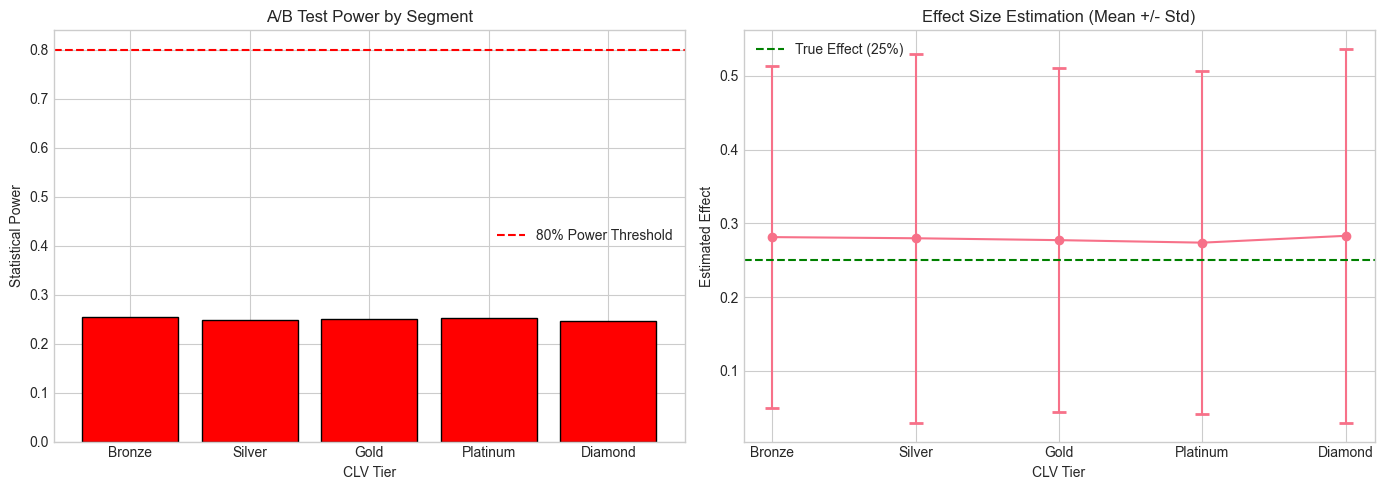

In [15]:
# Visualize power analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Power by segment
colors = ['red' if p < 0.8 else 'green' for p in power_df['statistical_power']]
axes[0].bar(power_df['segment'], power_df['statistical_power'], color=colors, edgecolor='black')
axes[0].axhline(0.8, color='red', linestyle='--', label='80% Power Threshold')
axes[0].set_xlabel('CLV Tier')
axes[0].set_ylabel('Statistical Power')
axes[0].set_title('A/B Test Power by Segment')
axes[0].legend()

# Effect estimation accuracy
axes[1].errorbar(power_df['segment'], power_df['avg_estimated_effect'], 
                 yerr=power_df['effect_std'], fmt='o-', capsize=5, capthick=2)
axes[1].axhline(0.25, color='green', linestyle='--', label='True Effect (25%)')
axes[1].set_xlabel('CLV Tier')
axes[1].set_ylabel('Estimated Effect')
axes[1].set_title('Effect Size Estimation (Mean +/- Std)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6. Summary & Export

In [16]:
# Summary
print("=" * 60)
print("FEEDBACK LOOP SUMMARY")
print("=" * 60)

print("\n1. SEGMENT EVOLUTION")
print(f"   - Simulated {len(evolution_df) // len(df)} periods of evolution")
print(f"   - Average retention rate: {retention_rates.mean():.1f}%")

print("\n2. CAMPAIGN PERFORMANCE")
print(f"   - {len(campaign_df)} campaigns simulated")
significant_campaigns = campaign_df['significant'].sum()
print(f"   - {significant_campaigns}/{len(campaign_df)} showed significant lift")
print(f"   - Best ROI: {campaign_df.loc[campaign_df['roi'].idxmax(), 'campaign_type']} ({campaign_df['roi'].max():.0f}%)")

print("\n3. MODEL MONITORING")
print(f"   - Monitored {len(monitoring_df)} periods")
print(f"   - {len(alerts_df)} alerts generated")
if len(alerts_df) > 0:
    high_alerts = (alerts_df['severity'] == 'HIGH').sum()
    print(f"   - {high_alerts} HIGH severity alerts")

print("\n4. A/B TESTING")
print(f"   - Power analysis for {len(power_df)} segments")
underpowered = (power_df['statistical_power'] < 0.8).sum()
print(f"   - {underpowered} segments underpowered for 25% effect detection")

FEEDBACK LOOP SUMMARY

1. SEGMENT EVOLUTION
   - Simulated 7 periods of evolution
   - Average retention rate: 52.2%

2. CAMPAIGN PERFORMANCE
   - 5 campaigns simulated
   - 2/5 showed significant lift
   - Best ROI: Win-Back Email (349%)

3. MODEL MONITORING
   - Monitored 12 periods
   - 0 alerts generated

4. A/B TESTING
   - Power analysis for 5 segments
   - 5 segments underpowered for 25% effect detection


In [17]:
# Export results
monitoring_df.to_csv('data/feedback_metrics.csv', index=False)
campaign_df.to_csv('data/campaign_results.csv', index=False)

print("\nExported:")
print("  - data/feedback_metrics.csv")
print("  - data/campaign_results.csv")


Exported:
  - data/feedback_metrics.csv
  - data/campaign_results.csv


In [18]:
# Recommendations
print("\n" + "=" * 60)
print("RECOMMENDATIONS")
print("=" * 60)

print("\n1. Model Retraining:")
if any(monitoring_df['auc'] < 0.7):
    print("   [ACTION REQUIRED] AUC dropped below 0.7 - retrain churn model")
else:
    print("   Model performance stable - schedule next review in 30 days")

print("\n2. Campaign Optimization:")
best_campaign = campaign_df.loc[campaign_df['roi'].idxmax()]
print(f"   Scale up: {best_campaign['campaign_type']} (ROI: {best_campaign['roi']:.0f}%)")

print("\n3. Sample Size Planning:")
for _, row in power_df[power_df['statistical_power'] < 0.8].iterrows():
    print(f"   {row['segment']}: Increase sample or accept larger MDE")

print("\n4. Segment Focus:")
print(f"   Highest retention: {retention_rates.idxmax()} ({retention_rates.max():.1f}%)")
print(f"   Needs attention: {retention_rates.idxmin()} ({retention_rates.min():.1f}%)")


RECOMMENDATIONS

1. Model Retraining:
   Model performance stable - schedule next review in 30 days

2. Campaign Optimization:
   Scale up: Win-Back Email (ROI: 349%)

3. Sample Size Planning:
   Bronze: Increase sample or accept larger MDE
   Silver: Increase sample or accept larger MDE
   Gold: Increase sample or accept larger MDE
   Platinum: Increase sample or accept larger MDE
   Diamond: Increase sample or accept larger MDE

4. Segment Focus:
   Highest retention: Diamond (97.0%)
   Needs attention: Silver (13.0%)
